### Objective:
### Analyze customer purchasing patterns, identify top customers,
### understand sales trends, and generate business insights.


📌 Cell 2 – Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


📌 Cell 3 – Load Datasets

In [2]:
sales_df = pd.read_csv("D:\Developer Arena\week_5\sales_data.csv")
customer_df = pd.read_csv("D:\Developer Arena\week_5\customer_churn.csv")

sales_df.head()


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


📌 Cell 4 – Data Exploration

In [3]:
sales_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [4]:
sales_df.describe()


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [5]:
sales_df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

📌 Cell 5 – Data Cleaning

In [6]:
# Standardize column names
sales_df.columns = sales_df.columns.str.lower().str.replace(" ", "_")
customer_df.columns = customer_df.columns.str.lower().str.replace(" ", "_")

# Convert date column
sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")

# Handle missing values
sales_df.fillna(0, inplace=True)


📌 Cell 6 – Feature Engineering

In [7]:
# Create total sales column
sales_df["total_sales"] = sales_df["quantity"] * sales_df["price"]

# Extract month
sales_df["order_month"] = sales_df["date"].dt.to_period("M").astype(str)


📌 Cell 7 – Data Merging

In [8]:
sales_df

,date,product,quantity,price,customer_id,region,total_sales,order_month
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024-01
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024-01
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024-01
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024-01
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024-01
...,...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160,2024-04
96,2024-04-06,Headphones,1,7647,CUST097,West,7647,2024-04
97,2024-04-07,Tablet,5,27196,CUST098,East,135980,2024-04
98,2024-04-08,Monitor,1,30717,CUST099,North,30717,2024-04


In [9]:
print(sales_df.columns)
print(customer_df.columns)


Index(['date', 'product', 'quantity', 'price', 'customer_id', 'region',
       'total_sales', 'order_month'],
      dtype='object')
Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract',
       'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn'],
      dtype='object')


In [13]:
sales_df.columns = sales_df.columns.str.strip().str.lower().str.replace("_", "")
customer_df.columns = customer_df.columns.str.strip().str.lower().str.replace(" ", "_")


In [14]:
print(sales_df.columns)
print(customer_df.columns)

Index(['date', 'product', 'quantity', 'price', 'customerid', 'region',
       'totalsales', 'ordermonth'],
      dtype='object')
Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract',
       'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn'],
      dtype='object')


In [15]:
merged_df = pd.merge(
    sales_df,
    customer_df,
    on ="customerid",
    how ="left"
)

def new_func(merged_df):
    merged_df.head()

new_func(merged_df)


📌 Cell 8 – Key Aggregations

In [17]:
# Total revenue
total_revenue = merged_df["totalsales"].sum()

# Average order value
avg_order_value = merged_df["totalsales"].mean()

# Total customers
total_customers = merged_df["customerid"].nunique()

total_revenue, avg_order_value, total_customers


(12365048, 123650.48, 100)

📌 Cell 9 – Top Customers Analysis

In [19]:
top_customers = (
    merged_df.groupby("customerid")["totalsales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers


customerid
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: totalsales, dtype: int64

📌 Cell 10 – Monthly Sales Trend

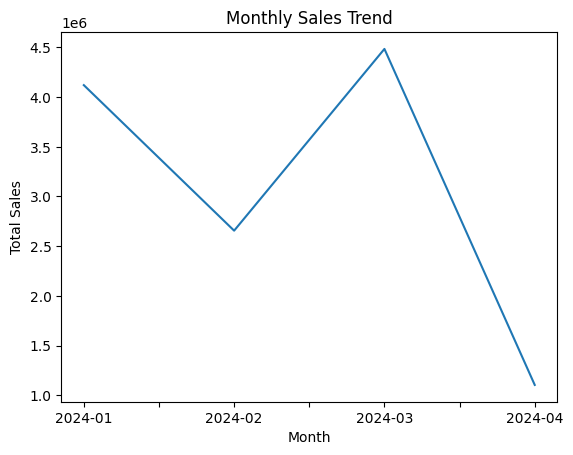

In [20]:
monthly_sales = merged_df.groupby("ordermonth")["totalsales"].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


📌 Cell 11 – Regional Sales Analysis

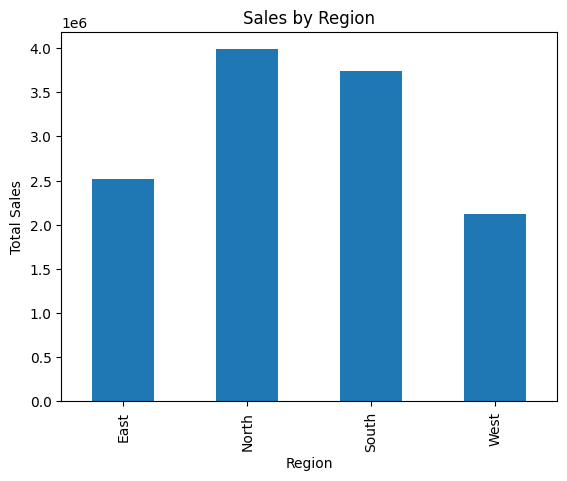

In [21]:
region_sales = merged_df.groupby("region")["totalsales"].sum()

plt.figure()
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


📌 Cell 12 – Best Selling Products

In [22]:
top_products = (
    merged_df.groupby("product")["totalsales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: totalsales, dtype: int64

📌 Cell 13 – Pivot Table Analysis

In [23]:
pivot_table = pd.pivot_table(
    merged_df,
    values="totalsales",
    index="product",
    columns="ordermonth",
    aggfunc="sum",
    fill_value=0
)

pivot_table


ordermonth,2024-01,2024-02,2024-03,2024-04
product,,,,
Headphones,241498,73396,687734,381405
Laptop,1981281,285064,1522863,100002
Monitor,67662,772321,477371,30717
Phone,937670,838792,1082932,0
Tablet,892413,686477,714106,591344


📌 Cell 14 – Customer Retention

In [29]:
customer_orders = merged_df.groupby("customerid")["date"].nunique()
retained_customers = customer_orders[customer_orders > 1].count()

retention_rate = (retained_customers / total_customers) * 100
retention_rate



0.0

📌 Cell 15 – Final Insights

In [30]:
print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Customer Retention Rate:", retention_rate)


Total Revenue: 12365048
Average Order Value: 123650.48
Customer Retention Rate: 0.0


https://docs.google.com/document/d/e/2PACX-1vTPwhYvCaAJt8JAHE8H-zY9bt7Ryqk-rA-jDzSjNh0iMsWeew5-o9K78fVfkM1CbouTz5d7x932Ryno/pub